# Neuro-Symbolic Counterfactual Explanations with ASP project


## 0. Notebook settings

In [2]:
%pip install -q clingo pandas scikit-learn numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 8.4 MB/s eta 0:00:00


## 1. Project Overview

**Project goals**

- Train a simple MLP classifier for the Adult Income prediction task.
- Use one test person as the input to the explanation system.
- Generate valid modified versions of that person with ASP.
- Find the smallest valid modification that changes the MLP prediction.
- Compare ASP-guided search with a random baseline.
- Evaluate validity, minimality, plausibility, and runtime.

**Input:** one person from the Adult Income dataset.

**Output:** a minimally modified version of the same person whose prediction flips.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", None)


def show_table_title(title, description=None):
    html = f"<h4 style='margin-bottom:4px'>{title}</h4>"
    if description:
        html += f"<p style='margin-top:0;color:#555'>{description}</p>"
    display(HTML(html))


def display_wrapped_table(df):
    html = df.to_html(index=False, escape=False)
    html = html.replace(
        '<table border="1" class="dataframe">',
        '<table border="1" class="dataframe" style="table-layout:auto;width:100%;white-space:normal;">',
    )
    html = html.replace("<td>", "<td style='white-space:normal;text-align:left;vertical-align:top;'>")
    html = html.replace("<th>", "<th style='white-space:normal;text-align:left;vertical-align:top;'>")
    display(HTML(html))

## 2. Dataset Loading

Upload `adult.csv` when prompted, or place it in the Colab file browser before running this cell.

In [4]:
from pathlib import Path

candidate_dataset_paths = [
    Path("/content/adult.csv"),
    Path("adult.csv"),
    Path("data/raw/adult.csv"),
    Path("sourceData/adult.csv"),
    Path("../data/raw/adult.csv"),
    Path("../sourceData/adult.csv"),
]
DATASET_PATH = next((path for path in candidate_dataset_paths if path.exists()), candidate_dataset_paths[0])

if not DATASET_PATH.exists():
    try:
        from google.colab import files
        uploaded = files.upload()
        if "adult.csv" in uploaded:
            DATASET_PATH = Path("/content/adult.csv")
        else:
            uploaded_name = next(iter(uploaded))
            Path(uploaded_name).rename("adult.csv")
            DATASET_PATH = Path("adult.csv")
    except ModuleNotFoundError:
        raise FileNotFoundError("Place adult.csv in the current working directory.")

print("Dataset is ready.")

Saving adult.csv to adult.csv
Dataset is ready.


## 3. Project Functions and ASP Knowledge Base

This cell defines the MLP pipeline, ASP facts generation, clingo execution, counterfactual search, random baseline, and evaluation helpers.

In [5]:
ASP_PROGRAM = r"""% Neuro-symbolic counterfactual search for the Adult Income dataset.
%
% This ASP file contains the symbolic knowledge base:
% - which features are editable or fixed
% - which changes are legal
% - which values are realistic
% - how to minimize the number of changed features

% ---------------------------------------------------------------------
% Editable and fixed features
% ---------------------------------------------------------------------

editable(hours).
editable(education).
editable(occupation).

fixed(age).
fixed(sex).

% ---------------------------------------------------------------------
% Legal value domains
% ---------------------------------------------------------------------

% Weekly hours can only move in small steps.
delta_hours(-10; -5; 0; 5; 10).

% Occupation changes are also local transitions.
can_change_occupation("Adm-clerical", "Exec-managerial").
can_change_occupation("Exec-managerial", "Adm-clerical").
can_change_occupation("Adm-clerical", "Sales").
can_change_occupation("Sales", "Adm-clerical").
can_change_occupation("Sales", "Tech-support").
can_change_occupation("Tech-support", "Sales").
can_change_occupation("Tech-support", "Prof-specialty").
can_change_occupation("Prof-specialty", "Tech-support").
can_change_occupation("Prof-specialty", "Exec-managerial").
can_change_occupation("Exec-managerial", "Prof-specialty").
can_change_occupation("Craft-repair", "Machine-op-inspct").
can_change_occupation("Machine-op-inspct", "Craft-repair").
can_change_occupation("Craft-repair", "Transport-moving").
can_change_occupation("Transport-moving", "Craft-repair").
can_change_occupation("Craft-repair", "Farming-fishing").
can_change_occupation("Farming-fishing", "Craft-repair").
can_change_occupation("Handlers-cleaners", "Other-service").
can_change_occupation("Other-service", "Handlers-cleaners").
can_change_occupation("Other-service", "Priv-house-serv").
can_change_occupation("Priv-house-serv", "Other-service").
can_change_occupation("Protective-serv", "Armed-Forces").
can_change_occupation("Armed-Forces", "Protective-serv").

% Education changes are local transitions only.
% This prevents unrealistic jumps such as Bachelors -> Doctorate.
can_change_education("Preschool", "1st-4th").
can_change_education("1st-4th", "Preschool").
can_change_education("1st-4th", "5th-6th").
can_change_education("5th-6th", "1st-4th").
can_change_education("5th-6th", "7th-8th").
can_change_education("7th-8th", "5th-6th").
can_change_education("7th-8th", "9th").
can_change_education("9th", "7th-8th").
can_change_education("9th", "10th").
can_change_education("10th", "9th").
can_change_education("10th", "11th").
can_change_education("11th", "10th").
can_change_education("11th", "12th").
can_change_education("12th", "11th").
can_change_education("12th", "HS-grad").
can_change_education("HS-grad", "12th").
can_change_education("HS-grad", "Some-college").
can_change_education("Some-college", "HS-grad").
can_change_education("Some-college", "Assoc-voc").
can_change_education("Assoc-voc", "Some-college").
can_change_education("Assoc-voc", "Assoc-acdm").
can_change_education("Assoc-acdm", "Assoc-voc").
can_change_education("Assoc-acdm", "Bachelors").
can_change_education("Bachelors", "Assoc-acdm").
can_change_education("Bachelors", "Masters").
can_change_education("Masters", "Bachelors").
can_change_education("Masters", "Prof-school").
can_change_education("Prof-school", "Masters").
can_change_education("Prof-school", "Doctorate").
can_change_education("Doctorate", "Prof-school").

% ---------------------------------------------------------------------
% Candidate generation
% ---------------------------------------------------------------------

1 { choose_hours(Delta) : delta_hours(Delta) } 1.
new_value(hours, NewHours) :-
    old_value(hours, Hours),
    choose_hours(Delta),
    NewHours = Hours + Delta.

new_value(education, Education) :-
    old_value(education, Education),
    not changed_education.

0 { changed_education } 1.
1 { new_value(education, NewEducation) : can_change_education(Education, NewEducation) } 1 :-
    old_value(education, Education),
    editable(education),
    changed_education.

new_value(occupation, Occupation) :-
    old_value(occupation, Occupation),
    not changed_occupation.

0 { changed_occupation } 1.
1 { new_value(occupation, NewOccupation) : can_change_occupation(Occupation, NewOccupation) } 1 :-
    old_value(occupation, Occupation),
    editable(occupation),
    changed_occupation.

new_value(Feature, Value) :-
    old_value(Feature, Value),
    fixed(Feature).

% ---------------------------------------------------------------------
% Validity constraints
% ---------------------------------------------------------------------

% Fixed features cannot change.
:- fixed(Feature), old_value(Feature, Old), new_value(Feature, New), Old != New.

% Hours must stay realistic.
:- new_value(hours, Hours), Hours < 1.
:- new_value(hours, Hours), Hours > 80.

% Changed occupations must follow the allowed transition graph.
:- old_value(occupation, Old), new_value(occupation, New), Old != New, not can_change_occupation(Old, New).

% ---------------------------------------------------------------------
% Change counting and minimality
% ---------------------------------------------------------------------

changed(hours) :-
    old_value(hours, Old),
    new_value(hours, New),
    Old != New.

changed(education) :-
    old_value(education, Old),
    new_value(education, New),
    Old != New.

changed(occupation) :-
    old_value(occupation, Old),
    new_value(occupation, New),
    Old != New.

% Python iterates over budgets 1, 2, 3.
% to inspect and still keeps ASP responsible for valid candidate generation.
:- change_budget(Budget), Budget != #count { Feature : changed(Feature) }.

#minimize { 1, Feature : changed(Feature) }.

#show new_value/2.
#show changed/1.
"""

from __future__ import annotations

import random
import time
from dataclasses import dataclass
from typing import Any

import clingo
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


FEATURES = ["age", "education", "hours.per.week", "occupation", "sex"]
TARGET = "income"
NUMERIC_FEATURES = ["age", "hours.per.week"]
CATEGORICAL_FEATURES = ["education", "occupation", "sex"]
EDITABLE_FEATURES = ["hours.per.week", "education", "occupation"]
FIXED_FEATURES = ["age", "sex"]

OCCUPATION_VALUES = [
    "Adm-clerical",
    "Armed-Forces",
    "Craft-repair",
    "Exec-managerial",
    "Farming-fishing",
    "Handlers-cleaners",
    "Machine-op-inspct",
    "Other-service",
    "Priv-house-serv",
    "Prof-specialty",
    "Protective-serv",
    "Sales",
    "Tech-support",
    "Transport-moving",
]

OCCUPATION_TRANSITIONS = {
    ("Adm-clerical", "Exec-managerial"),
    ("Exec-managerial", "Adm-clerical"),
    ("Adm-clerical", "Sales"),
    ("Sales", "Adm-clerical"),
    ("Sales", "Tech-support"),
    ("Tech-support", "Sales"),
    ("Tech-support", "Prof-specialty"),
    ("Prof-specialty", "Tech-support"),
    ("Prof-specialty", "Exec-managerial"),
    ("Exec-managerial", "Prof-specialty"),
    ("Craft-repair", "Machine-op-inspct"),
    ("Machine-op-inspct", "Craft-repair"),
    ("Craft-repair", "Transport-moving"),
    ("Transport-moving", "Craft-repair"),
    ("Craft-repair", "Farming-fishing"),
    ("Farming-fishing", "Craft-repair"),
    ("Handlers-cleaners", "Other-service"),
    ("Other-service", "Handlers-cleaners"),
    ("Other-service", "Priv-house-serv"),
    ("Priv-house-serv", "Other-service"),
    ("Protective-serv", "Armed-Forces"),
    ("Armed-Forces", "Protective-serv"),
}

EDUCATION_ORDER = [
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Some-college",
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Masters",
    "Prof-school",
    "Doctorate",
]

# Stores the full result of the counterfactual search process, including predictions,
# candidate examples, changed features, and runtime information.
@dataclass
class CounterfactualResult:
    found: bool
    original: pd.Series
    candidate: pd.Series | None
    original_prediction: int
    candidate_prediction: int | None
    changed_features: list[str]
    method: str
    runtime_seconds: float
    atoms: list[clingo.Symbol]
    search_steps: list[dict[str, Any]]


def load_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.copy()
    for column in df.select_dtypes(include="object").columns:
        df[column] = df[column].astype(str).str.strip()
    return df

# Selects the required features and removes missing or invalid records from the dataset.
def select_and_clean_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df[FEATURES + [TARGET]].copy()
    data = data.replace("?", np.nan).dropna().reset_index(drop=True)
    data = data[data[TARGET].isin(["<=50K", ">50K"])].reset_index(drop=True)
    return data


def split_dataset(data: pd.DataFrame, test_size: float = 0.2, random_state: int = 42):
    x = data[FEATURES].copy()
    y = data[TARGET].map({"<=50K": 0, ">50K": 1}).astype(int)
    return train_test_split(x, y, test_size=test_size, random_state=random_state, stratify=y)


def build_mlp_model(random_state: int = 42) -> Pipeline:
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC_FEATURES),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ]
    )
    # ReLU activation was used because it provides efficient optimization
    # and stable gradient propagation in neural networks
    classifier = MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        alpha=0.0005,
        batch_size=128,
        learning_rate_init=0.001,
        max_iter=120,
        early_stopping=True,
        n_iter_no_change=8,
        random_state=random_state,
    )
    return Pipeline([("preprocess", preprocessor), ("classifier", classifier)])


def train_mlp(x_train: pd.DataFrame, y_train: pd.Series) -> Pipeline:
    model = build_mlp_model()
    model.fit(x_train, y_train)
    return model


def evaluate_classifier(model: Pipeline, x_test: pd.DataFrame, y_test: pd.Series) -> dict[str, Any]:
    y_pred = model.predict(x_test)
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "report": classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]),
        "report_table": pd.DataFrame(
            classification_report(
                y_test,
                y_pred,
                target_names=["<=50K", ">50K"],
                output_dict=True,
            )
        ).T,
    }

# Converts python strings into safe ASP-compatible string literals
def clingo_string(value: str) -> str:
    escaped = str(value).replace("\\", "\\\\").replace('"', '\\"')
    return f'"{escaped}"'

# Converts one dataset example into ASP facts representing the original person
def person_to_asp_facts(person: pd.Series) -> str:
    return "\n".join(
        [
            f"old_value(age, {int(person['age'])}).",
            f"old_value(sex, {clingo_string(person['sex'])}).",
            f"old_value(education, {clingo_string(person['education'])}).",
            f"old_value(hours, {int(person['hours.per.week'])}).",
            f"old_value(occupation, {clingo_string(person['occupation'])}).",
        ]
    )


# extracts standard python values from Clingo symbolic objects
def _symbol_value(symbol: clingo.Symbol) -> Any:
    if symbol.type == clingo.SymbolType.Number:
        return symbol.number
    if symbol.type == clingo.SymbolType.String:
        return symbol.string
    if symbol.type == clingo.SymbolType.Function:
        return symbol.name
    return str(symbol)


# Converts ASP-generated atoms into a modified candidate example
def atoms_to_person(original: pd.Series, atoms: list[clingo.Symbol]) -> pd.Series:
    candidate = original.copy()
    for atom in atoms:
        if atom.name != "new_value" or len(atom.arguments) != 2:
            continue
        feature = atom.arguments[0].name
        value = _symbol_value(atom.arguments[1])
        if feature == "hours":
            candidate["hours.per.week"] = int(value)
        elif feature in {"age", "education", "occupation", "sex"}:
            candidate[feature] = value
    return candidate


# identifies which features were modified in the counterfactual example
def changed_features(original: pd.Series, candidate: pd.Series) -> list[str]:
    return [feature for feature in FEATURES if original[feature] != candidate[feature]]


def asp_candidates(
    person: pd.Series,
    data: pd.DataFrame,
    asp_template: Path,
    budget: int,
    max_models: int = 80,
) -> list[list[clingo.Symbol]]:
    ctl = clingo.Control([f"--models={max_models}", "--opt-mode=optN"])
    program = "\n".join(
        [
            ASP_PROGRAM,
            person_to_asp_facts(person),
            f"change_budget({budget}).",
        ]
    )
    ctl.add("base", [], program)
    # ASP changes variables with exact values
    ctl.ground([("base", [])])

    models: list[list[clingo.Symbol]] = []
    seen_models: set[tuple[str, ...]] = set()
    # generate answer sets
    with ctl.solve(yield_=True) as handle:
        for model in handle:
            atoms = model.symbols(shown=True)
            key = tuple(sorted(str(atom) for atom in atoms))
            if key in seen_models:
                continue
            seen_models.add(key)
            models.append(atoms)
    return models

# this function predicts the income class for a single person using the trained MLP pipeline.
def predict_one(model: Pipeline, person: pd.Series) -> int:
    return int(model.predict(pd.DataFrame([person[FEATURES]]))[0])


def change_details(original: pd.Series, candidate: pd.Series) -> str:
    details = []
    for feature in changed_features(original, candidate):
        details.append(f"{feature}: {original[feature]} -> {candidate[feature]}")
    return "; ".join(details) if details else "no changes"


# function converts the counterfactual search trace
# into a structured table for analysis
def search_steps_dataframe(result: CounterfactualResult) -> pd.DataFrame:
    columns = [
        "step",
        "budget",
        "candidate_prediction",
        "flipped",
        "n_changed_features",
        "changes",
    ]
    if not result.search_steps:
        return pd.DataFrame(columns=columns)
    return pd.DataFrame(result.search_steps)[columns]


def comparison_table(original: pd.Series, candidate: pd.Series | None) -> pd.DataFrame:
    if candidate is None:
        return pd.DataFrame([original[FEATURES]], index=["original"])
    return pd.DataFrame([original[FEATURES], candidate[FEATURES]], index=["original", "counterfactual"])

# function searches for valid ASP-guided counterfactual by gradually
# increasing the allowed number of changed features and stopping when the model prediction flips
def find_asp_counterfactual(
    person: pd.Series,
    model: Pipeline,
    data: pd.DataFrame,
    asp_template: Path,
    max_changes: int = 3,
    max_models_per_budget: int = 80,
) -> CounterfactualResult:
    # count time
    start = time.perf_counter()
    original_prediction = predict_one(model, person)
    search_steps: list[dict[str, Any]] = []
    step = 0

    # function searches for 1,2, 3 changes for counterfactual
    for budget in range(1, max_changes + 1):
        for atoms in asp_candidates(person, data, asp_template, budget, max_models_per_budget):
            step += 1
            candidate = atoms_to_person(person, atoms)
            candidate_prediction = predict_one(model, candidate)
            flipped = candidate_prediction != original_prediction
            changed = changed_features(person, candidate)
            search_steps.append(
                {
                    "step": step,
                    "budget": budget,
                    "candidate_prediction": label_name(candidate_prediction),
                    "flipped": flipped,
                    "n_changed_features": len(changed),
                    "changes": change_details(person, candidate),
                }
            )
            # if candidate found then flip
            if flipped:
                return CounterfactualResult(
                    found=True,
                    original=person,
                    candidate=candidate,
                    original_prediction=original_prediction,
                    candidate_prediction=candidate_prediction,
                    changed_features=changed_features(person, candidate),
                    method="asp_guided",
                    runtime_seconds=time.perf_counter() - start,
                    atoms=atoms,
                    search_steps=search_steps,
                )

    return CounterfactualResult(
        found=False,
        original=person,
        candidate=None,
        original_prediction=original_prediction,
        candidate_prediction=None,
        changed_features=[],
        method="asp_guided",
        runtime_seconds=time.perf_counter() - start,
        atoms=[],
        search_steps=search_steps,
    )

# creates a random modified candidate
# by changing editable features without using ASP constraints
def random_candidate(
    person: pd.Series,
    data: pd.DataFrame,
    rng: random.Random,
    max_changes: int = 2,
) -> pd.Series:
    candidate = person.copy()
    number_of_changes = rng.randint(1, max_changes)
    chosen_features = rng.sample(EDITABLE_FEATURES, number_of_changes)

    if "hours.per.week" in chosen_features:
        delta = rng.choice([-10, -5, 5, 10])
        candidate["hours.per.week"] = int(np.clip(candidate["hours.per.week"] + delta, 1, 80))

    if "education" in chosen_features:
        values = [value for value in data["education"].unique() if value != person["education"]]
        candidate["education"] = rng.choice(values)

    if "occupation" in chosen_features:
        values = [value for value in data["occupation"].unique() if value != person["occupation"]]
        candidate["occupation"] = rng.choice(values)

    return candidate

# implements the random baseline by repeatedly
# generating random candidates and checking whether any of them flips the prediction
def find_random_counterfactual(
    person: pd.Series,
    model: Pipeline,
    data: pd.DataFrame,
    max_changes: int = 2,
    attempts: int = 200,
    seed: int = 42,
) -> CounterfactualResult:
    start = time.perf_counter()
    rng = random.Random(seed)
    original_prediction = predict_one(model, person)
    search_steps: list[dict[str, Any]] = []

    for step in range(1, attempts + 1):
        candidate = random_candidate(person, data, rng, max_changes=max_changes)
        candidate_prediction = predict_one(model, candidate)
        flipped = candidate_prediction != original_prediction
        changed = changed_features(person, candidate)
        search_steps.append(
            {
                "step": step,
                "budget": len(changed),
                "candidate_prediction": label_name(candidate_prediction),
                "flipped": flipped,
                "n_changed_features": len(changed),
                "changes": change_details(person, candidate),
            }
        )
        if flipped:
            return CounterfactualResult(
                found=True,
                original=person,
                candidate=candidate,
                original_prediction=original_prediction,
                candidate_prediction=candidate_prediction,
                changed_features=changed_features(person, candidate),
                method="random_baseline",
                runtime_seconds=time.perf_counter() - start,
                atoms=[],
                search_steps=search_steps,
            )

    return CounterfactualResult(
        found=False,
        original=person,
        candidate=None,
        original_prediction=original_prediction,
        candidate_prediction=None,
        changed_features=[],
        method="random_baseline",
        runtime_seconds=time.perf_counter() - start,
        atoms=[],
        search_steps=search_steps,
    )

# checking whether the education change is local and therefore plausible.
def education_transition_allowed(old: str, new: str) -> bool:
    if old == new:
        return True
    if old not in EDUCATION_ORDER or new not in EDUCATION_ORDER:
        return False
    return abs(EDUCATION_ORDER.index(old) - EDUCATION_ORDER.index(new)) == 1


def allowed_occupations() -> set[str]:
    return set(OCCUPATION_VALUES)


def occupation_transition_allowed(old: str, new: str) -> bool:
    return old == new or (old, new) in OCCUPATION_TRANSITIONS


def constraints_satisfied(result: CounterfactualResult, data: pd.DataFrame | None = None) -> bool:
    if not result.found or result.candidate is None:
        return False
    if result.original["age"] != result.candidate["age"]:
        return False
    if result.original["sex"] != result.candidate["sex"]:
        return False
    hours = int(result.candidate["hours.per.week"])
    if not 1 <= hours <= 80:
        return False
    if not education_transition_allowed(result.original["education"], result.candidate["education"]):
        return False
    if data is not None and result.original["occupation"] != result.candidate["occupation"]:
        if not occupation_transition_allowed(result.original["occupation"], result.candidate["occupation"]):
            return False
    return True


def result_to_row(index: int, result: CounterfactualResult, data: pd.DataFrame | None = None) -> dict[str, Any]:
    return {
        "example_index": index,
        "method": result.method,
        "found": result.found,
        "original_prediction": result.original_prediction,
        "candidate_prediction": result.candidate_prediction,
        "changed_features": ", ".join(result.changed_features),
        "n_changed_features": len(result.changed_features) if result.found else np.nan,
        "plausible": constraints_satisfied(result, data),
        "runtime_seconds": result.runtime_seconds,
    }


# Evaluates the ASP-guided and random baseline
# methods on multiple examples and collects their results
def evaluate_counterfactual_methods(
    x_examples: pd.DataFrame,
    model: Pipeline,
    data: pd.DataFrame,
    asp_template: Path,
    n_examples: int = 25,
) -> tuple[pd.DataFrame, list[CounterfactualResult]]:
    rows: list[dict[str, Any]] = []
    results: list[CounterfactualResult] = []
    examples = x_examples.head(n_examples)

    for position, (_, person) in enumerate(examples.iterrows()):
        asp_result = find_asp_counterfactual(person, model, data, asp_template)
        random_result = find_random_counterfactual(person, model, data, seed=42 + position)
        results.extend([asp_result, random_result])
        rows.append(result_to_row(position, asp_result, data))
        rows.append(result_to_row(position, random_result, data))

    return pd.DataFrame(rows), results


# aggregate evaluation metrics for each counterfactual generation method
def summarize_evaluation(evaluation: pd.DataFrame) -> pd.DataFrame:
    return (
        evaluation.groupby("method", as_index=False)
        .agg(
            validity=("found", "mean"),
            minimality=("n_changed_features", "mean"),
            plausibility=("plausible", "mean"),
            avg_runtime_seconds=("runtime_seconds", "mean"),
        )
        .sort_values("method")
    )


def label_name(label: int | None) -> str:
    if label is None:
        return "not found"
    return ">50K" if int(label) == 1 else "<=50K"


# natural-language explanation describing how the counterfactual changes
# flipped the prediction
def describe_counterfactual(result: CounterfactualResult) -> str:
    if not result.found or result.candidate is None:
        return (
            f"{result.method}: no counterfactual found for a person predicted "
            f"{label_name(result.original_prediction)}."
        )

    changes = []
    for feature in result.changed_features:
        old = result.original[feature]
        new = result.candidate[feature]
        changes.append(f"{feature} changed from {old} to {new}")

    return (
        f"{result.method}: prediction changed from {label_name(result.original_prediction)} "
        f"to {label_name(result.candidate_prediction)} when "
        f"{'; '.join(changes)}."
    )


## 4. Dataset Inspection and Feature Selection

Load the dataset, keep the required features, and remove rows with missing categorical values.

In [6]:
raw_df = load_dataset(DATASET_PATH)
data = select_and_clean_features(raw_df)

dataset_info = pd.DataFrame(
    {
        "metric": ["raw rows", "raw columns", "clean rows", "selected features"],
        "value": [raw_df.shape[0], raw_df.shape[1], len(data), len(FEATURES)],
    }
)
feature_table = pd.DataFrame(
    {
        "role": ["numeric", "numeric", "categorical", "categorical", "categorical", "target"],
        "column": ["age", "hours.per.week", "education", "occupation", "sex", "income"],
    }
)

show_table_title("Dataset size after loading and cleaning")
display(dataset_info)
display(HTML("<hr style='height:3px;border:none;background-color:#999;'>"))
show_table_title("Selected project columns", "Only these columns are used for the MLP and counterfactual search.")
display(feature_table)
display(HTML("<hr style='height:3px;border:none;background-color:#999;'>"))
show_table_title("First cleaned rows")
display(data.head())

,metric,value
0,raw rows,32561
1,raw columns,15
2,clean rows,30718
3,selected features,5


,role,column
0,numeric,age
1,numeric,hours.per.week
2,categorical,education
3,categorical,occupation
4,categorical,sex
5,target,income


,age,education,hours.per.week,occupation,sex,income
0,82,HS-grad,18,Exec-managerial,Female,<=50K
1,54,7th-8th,40,Machine-op-inspct,Female,<=50K
2,41,Some-college,40,Prof-specialty,Female,<=50K
3,34,HS-grad,45,Other-service,Female,<=50K
4,38,10th,40,Adm-clerical,Male,<=50K


## 5. Preprocessing

Scale numeric features, one-hot encode categorical features, and create a stratified train-test split.

In [7]:
X_train, X_test, y_train, y_test = split_dataset(data)

split_table = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "columns": [X_train.shape[1], X_test.shape[1]],
    }
)
class_balance = (
    y_train.value_counts(normalize=True)
    .rename(index={0: "<=50K", 1: ">50K"})
    .rename("share")
    .reset_index()
    .rename(columns={"income": "class", "index": "class"})
)
class_balance["share"] = class_balance["share"].round(3)

show_table_title("Train-test split size")
display(split_table)
display(HTML("<hr style='height:3px;border:none;background-color:#999;'>"))
show_table_title("Income class balance in the training set")
display(class_balance)

,split,rows,columns
0,train,24574,5
1,test,6144,5


,class,share
0,<=50K,0.751
1,>50K,0.249


## 6. MLP Training

Train the required simple MLP with two small hidden layers and ReLU activation.

In [8]:
mlp_model = train_mlp(X_train, y_train)
classification_metrics = evaluate_classifier(mlp_model, X_test, y_test)

accuracy_table = pd.DataFrame(
    {"metric": ["MLP accuracy"], "value": [round(classification_metrics["accuracy"], 4)]}
)
report_table = classification_metrics["report_table"].round(3)

show_table_title("Overall MLP accuracy")
display(accuracy_table)
display(HTML("<hr style='height:3px;border:none;background-color:#999;'>"))
show_table_title("Classification report", "Precision, recall, and F1-score for both income classes.")
display(report_table)

,metric,value
0,MLP accuracy,0.8122


,precision,recall,f1-score,support
<=50K,0.844,0.920,0.880,4614.000
>50K,0.668,0.488,0.564,1530.000
accuracy,0.812,0.812,0.812,0.812
macro avg,0.756,0.704,0.722,6144.000
weighted avg,0.800,0.812,0.802,6144.000


## 7. Original Prediction Example

Use a test example that gives a clear successful ASP.

In [9]:
example_positions = [4, 7, 14, 16, 17]
example_people = [X_test.iloc[position] for position in example_positions]
example_person = example_people[0]
original_prediction = predict_one(mlp_model, example_person)

show_table_title("Main example used for detailed ASP facts")
display(example_person[FEATURES].to_frame(name="value"))
display(HTML("<hr style='height:3px;border:none;background-color:#999;'>"))
show_table_title("Original prediction for the main example")
display(pd.DataFrame({"item": ["original prediction"], "value": [label_name(original_prediction)]}))

,value
age,53
education,Some-college
hours.per.week,50
occupation,Sales
sex,Male


,item,value
0,original prediction,>50K


## 8. ASP Facts Generation

Convert the selected person into `old_value/2` facts.

In [10]:
facts = person_to_asp_facts(example_person)
print(facts)

old_value(age, 53).
old_value(sex, "Male").
old_value(education, "Some-college").
old_value(hours, 50).
old_value(occupation, "Sales").


## 9. ASP Knowledge Base and Clingo Candidates

The ASP knowledge base defines fixed features, editable features, legal changes, constraints, and minimality.

In [11]:
print(ASP_PROGRAM)

% Neuro-symbolic counterfactual search for the Adult Income dataset.
%
% This ASP file contains the symbolic knowledge base:
% - which features are editable or fixed
% - which changes are legal
% - which values are realistic
% - how to minimize the number of changed features

% ---------------------------------------------------------------------
% Editable and fixed features
% ---------------------------------------------------------------------

editable(hours).
editable(education).
editable(occupation).

fixed(age).
fixed(sex).

% ---------------------------------------------------------------------
% Legal value domains
% ---------------------------------------------------------------------

% Weekly hours can only move in small steps.
delta_hours(-10; -5; 0; 5; 10).

% Occupation changes are also local transitions.
can_change_occupation("Adm-clerical", "Exec-managerial").
can_change_occupation("Exec-managerial", "Adm-clerical").
can_change_occupation("Adm-clerical", "Sales").
can_

In [12]:
candidate_atom_sets = asp_candidates(
    person=example_person,
    data=data,
    asp_template=None,
    budget=1,
    max_models=5,
)
candidate_rows = []
for candidate_id, atoms in enumerate(candidate_atom_sets, start=1):
    candidate_person = atoms_to_person(example_person, atoms)

    for feature in FEATURES:
        original_value = example_person[feature]
        candidate_value = candidate_person[feature]

        original_atom_str = f"{feature}: {original_value}"
        changed_atom_str = f"{feature}: {candidate_value}" if original_value != candidate_value else "-"

        candidate_rows.append({
            "candidate": candidate_id,
            "atom original": original_atom_str,
            "atom changed": changed_atom_str
        })

show_table_title("First ASP-generated candidates", "Each candidate is a possible modified person produced under a one-change budget.")
display(pd.DataFrame(candidate_rows))

,candidate,atom original,atom changed
0,1,age: 53,-
1,1,education: Some-college,education: Assoc-voc
2,1,hours.per.week: 50,-
3,1,occupation: Sales,-
4,1,sex: Male,-
5,2,age: 53,-
6,2,education: Some-college,education: HS-grad
7,2,hours.per.week: 50,-
8,2,occupation: Sales,-
9,2,sex: Male,-


## 10. Counterfactual Search

Search starts with one changed feature. If no candidate flips the prediction, the change budget increases. This section shows five ASP-guided examples.

In [13]:
asp_results = [
    find_asp_counterfactual(
        person=person,
        model=mlp_model,
        data=data,
        asp_template=None,
        max_changes=2,
        max_models_per_budget=100,
    )
    for person in example_people
]
asp_result = asp_results[0]

asp_summary_rows = []
for example_id, result in enumerate(asp_results, start=1):
    asp_summary_rows.append({
        "example": example_id,
        "method": result.method,
        "counterfactual_found": result.found,
        "original_prediction": label_name(result.original_prediction),
        "counterfactual_prediction": label_name(result.candidate_prediction),
        "changed_features": ", ".join(result.changed_features) if result.changed_features else "none",
        "runtime_seconds": round(result.runtime_seconds, 3),
    })

show_table_title("ASP-guided counterfactual summary for five examples")
display(pd.DataFrame(asp_summary_rows))

display(HTML("<hr style='height:3px;border:none;background-color:#999;'>"))
show_table_title(
    "Detailed ASP search steps for five examples",
    "Each row is one candidate generated by ASP and checked by the MLP. For each example, the search stops at the first prediction flip.",
)
all_asp_steps = []
for example_id, result in enumerate(asp_results, start=1):
    steps = search_steps_dataframe(result).copy()
    steps.insert(0, "example", example_id)
    all_asp_steps.append(steps)

asp_steps_table = pd.concat(all_asp_steps, ignore_index=True).rename(
    columns={
        "step": "candidate_id",
        "budget": "allowed_number_of_changes",
        "candidate_prediction": "prediction_for_this_candidate",
        "flipped": "prediction_flipped",
        "n_changed_features": "actual_number_of_changed_features",
        "changes": "candidate_changes",
    }
)
display_wrapped_table(asp_steps_table)

display(HTML("<hr style='height:3px;border:none;background-color:#999;'>"))
show_table_title("Original instances vs. ASP counterfactuals for five examples")
asp_comparison_tables = []
for example_id, result in enumerate(asp_results, start=1):
    table = comparison_table(result.original, result.candidate).reset_index().rename(columns={"index": "row_type"})
    table.insert(0, "example", example_id)
    asp_comparison_tables.append(table)

display_wrapped_table(pd.concat(asp_comparison_tables, ignore_index=True))

,example,method,counterfactual_found,original_prediction,counterfactual_prediction,changed_features,runtime_seconds
0,1,asp_guided,True,>50K,<=50K,occupation,0.053
1,2,asp_guided,True,>50K,<=50K,occupation,0.048
2,3,asp_guided,True,>50K,<=50K,education,0.031
3,4,asp_guided,True,>50K,<=50K,occupation,0.057
4,5,asp_guided,True,>50K,<=50K,education,0.025


example,candidate_id,allowed_number_of_changes,prediction_for_this_candidate,prediction_flipped,actual_number_of_changed_features,candidate_changes
1,1,1,>50K,False,1,education: Some-college -> Assoc-voc
1,2,1,>50K,False,1,education: Some-college -> HS-grad
1,3,1,>50K,False,1,occupation: Sales -> Tech-support
1,4,1,<=50K,True,1,occupation: Sales -> Adm-clerical
2,1,1,>50K,False,1,education: Some-college -> Assoc-voc
2,2,1,>50K,False,1,education: Some-college -> HS-grad
2,3,1,>50K,False,1,occupation: Sales -> Tech-support
2,4,1,<=50K,True,1,occupation: Sales -> Adm-clerical
3,1,1,>50K,False,1,education: HS-grad -> Some-college
3,2,1,<=50K,True,1,education: HS-grad -> 12th


example,row_type,age,education,hours.per.week,occupation,sex
1,original,53,Some-college,50,Sales,Male
1,counterfactual,53,Some-college,50,Adm-clerical,Male
2,original,53,Some-college,55,Sales,Male
2,counterfactual,53,Some-college,55,Adm-clerical,Male
3,original,51,HS-grad,40,Prof-specialty,Male
3,counterfactual,51,12th,40,Prof-specialty,Male
4,original,46,Bachelors,44,Craft-repair,Male
4,counterfactual,46,Bachelors,44,Farming-fishing,Male
5,original,57,Some-college,40,Prof-specialty,Male
5,counterfactual,57,Assoc-voc,40,Prof-specialty,Male


## 11. Random Baseline

The random baseline changes editable features without using ASP rules. This section also shows five examples, using a maximum change budget of 2.

In [14]:
random_results = [
    find_random_counterfactual(
        person=person,
        model=mlp_model,
        data=data,
        max_changes=2,
        attempts=100,
        seed=42 + example_id,
    )
    for example_id, person in enumerate(example_people, start=1)
]
random_result = random_results[0]

random_summary_rows = []
for example_id, result in enumerate(random_results, start=1):
    random_summary_rows.append({
        "example": example_id,
        "method": result.method,
        "counterfactual_found": result.found,
        "original_prediction": label_name(result.original_prediction),
        "counterfactual_prediction": label_name(result.candidate_prediction),
        "changed_features": ", ".join(result.changed_features) if result.changed_features else "none",
        "runtime_seconds": round(result.runtime_seconds, 3),
    })

show_table_title("Random baseline summary for five examples", "The random baseline uses a maximum change budget of 2.")
display(pd.DataFrame(random_summary_rows))

display(HTML("<hr style='height:3px;border:none;background-color:#999;'>"))
show_table_title("Random search steps for five examples")
all_random_steps = []
for example_id, result in enumerate(random_results, start=1):
    steps = search_steps_dataframe(result).copy()
    steps.insert(0, "example", example_id)
    all_random_steps.append(steps)

random_steps_table = pd.concat(all_random_steps, ignore_index=True).rename(
    columns={
        "step": "candidate_id",
        "budget": "number_of_random_changes",
        "candidate_prediction": "prediction_for_this_candidate",
        "flipped": "prediction_flipped",
        "n_changed_features": "actual_number_of_changed_features",
        "changes": "candidate_changes",
    }
)
display_wrapped_table(random_steps_table)

display(HTML("<hr style='height:3px;border:none;background-color:#999;'>"))
show_table_title("Original instances vs. random counterfactuals for five examples")
random_comparison_tables = []
for example_id, result in enumerate(random_results, start=1):
    table = comparison_table(result.original, result.candidate).reset_index().rename(columns={"index": "row_type"})
    table.insert(0, "example", example_id)
    random_comparison_tables.append(table)

display_wrapped_table(pd.concat(random_comparison_tables, ignore_index=True))

,example,method,counterfactual_found,original_prediction,counterfactual_prediction,changed_features,runtime_seconds
0,1,random_baseline,True,>50K,<=50K,education,0.025
1,2,random_baseline,True,>50K,<=50K,"hours.per.week, occupation",0.022
2,3,random_baseline,True,>50K,<=50K,"education, hours.per.week",0.041
3,4,random_baseline,True,>50K,<=50K,education,0.021
4,5,random_baseline,True,>50K,<=50K,education,0.049


example,candidate_id,number_of_random_changes,prediction_for_this_candidate,prediction_flipped,actual_number_of_changed_features,candidate_changes
1,1,1,<=50K,True,1,education: Some-college -> 5th-6th
2,1,2,<=50K,True,2,hours.per.week: 55 -> 50; occupation: Sales -> Transport-moving
3,1,2,>50K,False,2,education: HS-grad -> Prof-school; occupation: Prof-specialty -> Machine-op-inspct
3,2,2,<=50K,True,2,education: HS-grad -> 11th; hours.per.week: 40 -> 30
4,1,1,<=50K,True,1,education: Bachelors -> HS-grad
5,1,2,>50K,False,2,education: Some-college -> Assoc-voc; hours.per.week: 40 -> 50
5,2,2,>50K,False,2,education: Some-college -> Masters; occupation: Prof-specialty -> Tech-support
5,3,1,<=50K,True,1,education: Some-college -> 1st-4th


example,row_type,age,education,hours.per.week,occupation,sex
1,original,53,Some-college,50,Sales,Male
1,counterfactual,53,5th-6th,50,Sales,Male
2,original,53,Some-college,55,Sales,Male
2,counterfactual,53,Some-college,50,Transport-moving,Male
3,original,51,HS-grad,40,Prof-specialty,Male
3,counterfactual,51,11th,30,Prof-specialty,Male
4,original,46,Bachelors,44,Craft-repair,Male
4,counterfactual,46,HS-grad,44,Craft-repair,Male
5,original,57,Some-college,40,Prof-specialty,Male
5,counterfactual,57,1st-4th,40,Prof-specialty,Male


## 12. Evaluation

Evaluate the selected examples and then run a larger 100-example comparison. For each person, both methods have the same maximum change budget and the same maximum number of checked candidates.

example,method,changed_features,prediction_flipped,original_prediction,prediction_after_changes,runtime_seconds
1,ASP-guided,occupation,True,>50K,<=50K,0.053
2,ASP-guided,occupation,True,>50K,<=50K,0.048
3,ASP-guided,education,True,>50K,<=50K,0.031
4,ASP-guided,occupation,True,>50K,<=50K,0.057
5,ASP-guided,education,True,>50K,<=50K,0.025
1,Random baseline,education,True,>50K,<=50K,0.025
2,Random baseline,"hours.per.week, occupation",True,>50K,<=50K,0.022
3,Random baseline,"education, hours.per.week",True,>50K,<=50K,0.041
4,Random baseline,education,True,>50K,<=50K,0.021
5,Random baseline,education,True,>50K,<=50K,0.049


method,validity,minimality,plausibility,avg_runtime_seconds,avg_iterations_to_flip,successful_examples,total_examples
asp_guided,0.24,1.167,1.000,0.134,4.542,24,100
random_baseline,0.54,1.537,0.093,0.122,4.944,54,100


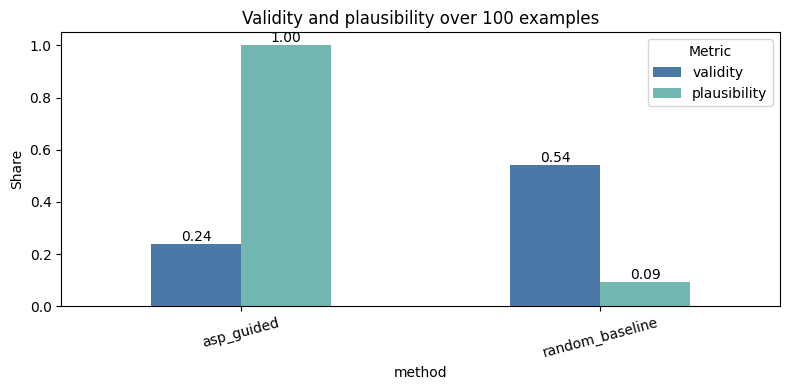

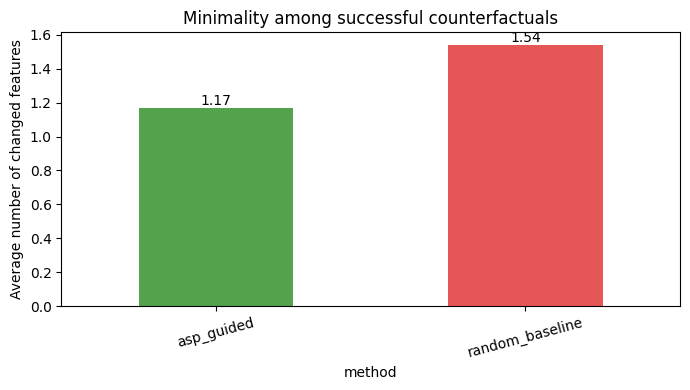

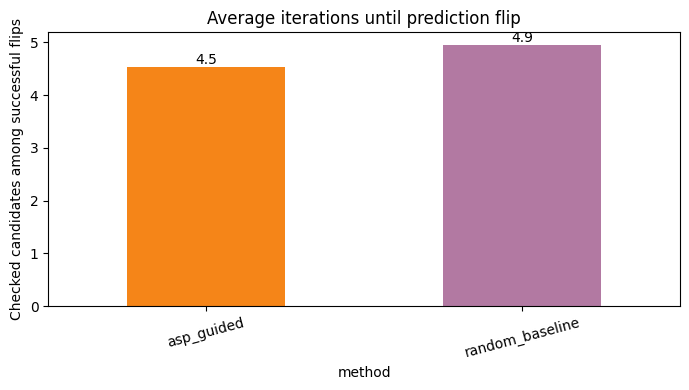

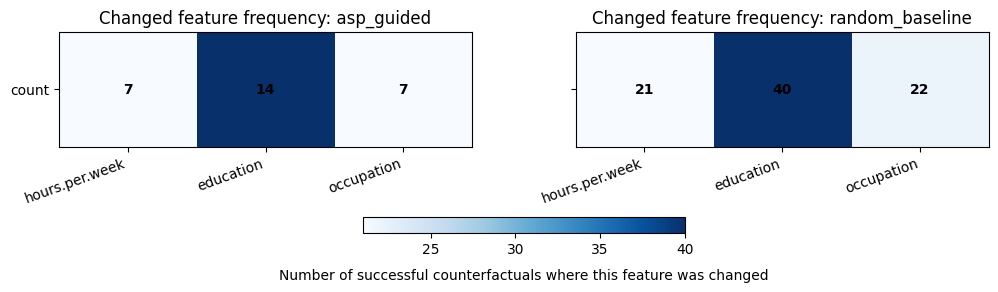

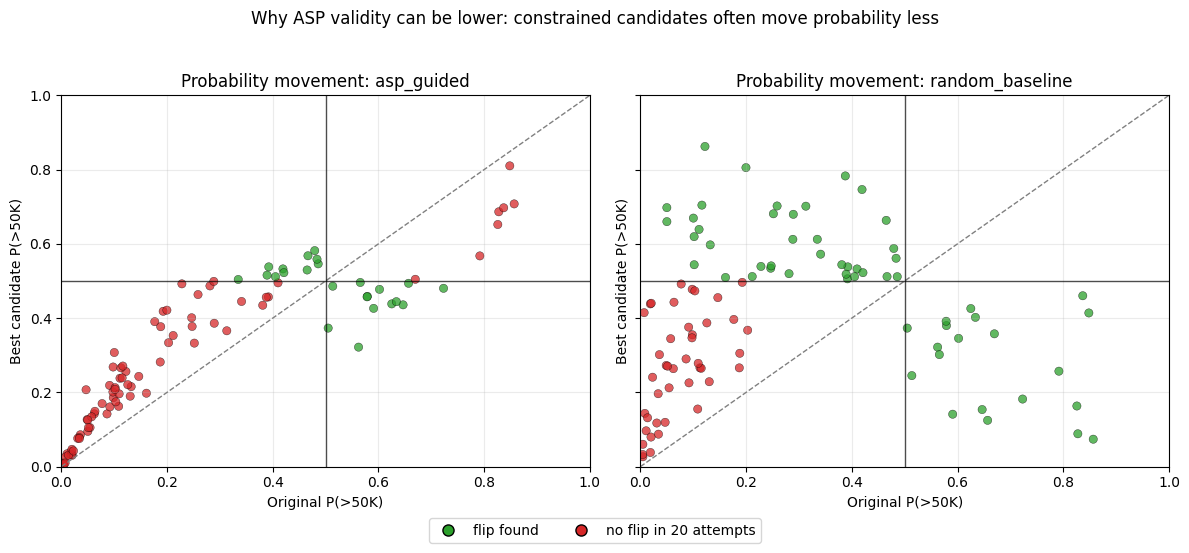

In [15]:
MAX_CHANGES = 2
MAX_ITERATIONS = 20

# This local evaluation function gives ASP the same total candidate-check limit
# as the random baseline: at most MAX_ITERATIONS checked candidates per person.
def find_asp_counterfactual_equal_budget(
    person,
    model,
    data,
    asp_template=None,
    max_changes=MAX_CHANGES,
    max_total_iterations=MAX_ITERATIONS,
):
    start = time.perf_counter()
    original_prediction = predict_one(model, person)
    search_steps = []
    checked_candidates = 0

    for budget in range(1, max_changes + 1):
        remaining_iterations = max_total_iterations - checked_candidates
        if remaining_iterations <= 0:
            break

        for atoms in asp_candidates(
            person=person,
            data=data,
            asp_template=asp_template,
            budget=budget,
            max_models=remaining_iterations,
        ):
            checked_candidates += 1
            candidate = atoms_to_person(person, atoms)
            candidate_prediction = predict_one(model, candidate)
            flipped = candidate_prediction != original_prediction
            changed = changed_features(person, candidate)
            search_steps.append(
                {
                    "step": checked_candidates,
                    "budget": budget,
                    "candidate_prediction": label_name(candidate_prediction),
                    "flipped": flipped,
                    "n_changed_features": len(changed),
                    "changes": change_details(person, candidate),
                }
            )

            if flipped:
                return CounterfactualResult(
                    found=True,
                    original=person,
                    candidate=candidate,
                    original_prediction=original_prediction,
                    candidate_prediction=candidate_prediction,
                    changed_features=changed,
                    method="asp_guided",
                    runtime_seconds=time.perf_counter() - start,
                    atoms=atoms,
                    search_steps=search_steps,
                )

            if checked_candidates >= max_total_iterations:
                break

    return CounterfactualResult(
        found=False,
        original=person,
        candidate=None,
        original_prediction=original_prediction,
        candidate_prediction=None,
        changed_features=[],
        method="asp_guided",
        runtime_seconds=time.perf_counter() - start,
        atoms=[],
        search_steps=search_steps,
    )


evaluation_rows = []
for example_id, result in enumerate(asp_results, start=1):
    evaluation_rows.append({
        "example": example_id,
        "method": "ASP-guided",
        "changed_features": ", ".join(result.changed_features) if result.changed_features else "none",
        "prediction_flipped": result.found,
        "original_prediction": label_name(result.original_prediction),
        "prediction_after_changes": label_name(result.candidate_prediction),
        "runtime_seconds": round(result.runtime_seconds, 3),
        "number_of_changes": len(result.changed_features) if result.found else 0,
        "plausible": constraints_satisfied(result, data) if result.found else None,
    })

for example_id, result in enumerate(random_results, start=1):
    evaluation_rows.append({
        "example": example_id,
        "method": "Random baseline",
        "changed_features": ", ".join(result.changed_features) if result.changed_features else "none",
        "prediction_flipped": result.found,
        "original_prediction": label_name(result.original_prediction),
        "prediction_after_changes": label_name(result.candidate_prediction),
        "runtime_seconds": round(result.runtime_seconds, 3),
        "number_of_changes": len(result.changed_features) if result.found else 0,
        "plausible": constraints_satisfied(result, data) if result.found else None,
    })

evaluation_examples = pd.DataFrame(evaluation_rows)

show_table_title(
    "Evaluation on the five selected examples",
    "This table compares what changed, whether the prediction flipped, the original and new prediction, and runtime.",
)
display_wrapped_table(evaluation_examples[[
    "example",
    "method",
    "changed_features",
    "prediction_flipped",
    "original_prediction",
    "prediction_after_changes",
    "runtime_seconds",
]])

display(HTML("<hr style='height:3px;border:none;background-color:#999;'>"))
show_table_title(
    "100-example evaluation run with equal 20-attempt limit",
    "Both methods use max_changes = 2 and at most 20 checked candidates per person. The 100 examples are used only as the evaluation sample size.",
)

large_rows = []
large_results = []
for example_id, (_, person) in enumerate(X_test.head(100).iterrows(), start=1):
    asp_large_result = find_asp_counterfactual_equal_budget(
        person=person,
        model=mlp_model,
        data=data,
        asp_template=None,
        max_changes=MAX_CHANGES,
        max_total_iterations=MAX_ITERATIONS,
    )
    random_large_result = find_random_counterfactual(
        person=person,
        model=mlp_model,
        data=data,
        max_changes=MAX_CHANGES,
        attempts=MAX_ITERATIONS,
        seed=500 + example_id,
    )
    large_results.extend([asp_large_result, random_large_result])

    for method_name, result in [("asp_guided", asp_large_result), ("random_baseline", random_large_result)]:
        large_rows.append({
            "example": example_id,
            "method": method_name,
            "found": result.found,
            "n_changed_features": len(result.changed_features) if result.found else None,
            "plausible_if_found": constraints_satisfied(result, data) if result.found else None,
            "runtime_seconds": result.runtime_seconds,
            "iterations_to_flip": len(result.search_steps) if result.found else None,
            "changed_features_list": result.changed_features if result.found else [],
        })

large_eval = pd.DataFrame(large_rows)

metric_rows = []
for method_name, group in large_eval.groupby("method"):
    found_group = group[group["found"] == True]
    metric_rows.append({
        "method": method_name,
        "validity": group["found"].mean(),
        "minimality": found_group["n_changed_features"].mean(),
        "plausibility": found_group["plausible_if_found"].mean(),
        "avg_runtime_seconds": group["runtime_seconds"].mean(),
        "avg_iterations_to_flip": found_group["iterations_to_flip"].mean(),
        "successful_examples": int(group["found"].sum()),
        "total_examples": len(group),
    })

large_metrics = pd.DataFrame(metric_rows).round(3)
display_wrapped_table(large_metrics)

# Graph 1: validity and plausibility are both shares, so they can be shown together.
fig, ax = plt.subplots(figsize=(8, 4))
vp_plot = large_metrics.set_index("method")[["validity", "plausibility"]]
vp_plot.plot(kind="bar", ax=ax, color=["#4C78A8", "#72B7B2"])
ax.set_title("Validity and plausibility over 100 examples")
ax.set_ylabel("Share")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Metric")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.tight_layout()
plt.show()

# Graph 2: minimality is a count, so it is shown separately.
fig, ax = plt.subplots(figsize=(7, 4))
minimality_plot = large_metrics.set_index("method")["minimality"]
minimality_plot.plot(kind="bar", ax=ax, color=["#54A24B", "#E45756"])
ax.set_title("Minimality among successful counterfactuals")
ax.set_ylabel("Average number of changed features")
ax.tick_params(axis="x", rotation=15)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.tight_layout()
plt.show()

# Graph 3: iterations are averaged only over examples where a flip was actually found.
fig, ax = plt.subplots(figsize=(7, 4))
iterations_plot = large_metrics.set_index("method")["avg_iterations_to_flip"]
iterations_plot.plot(kind="bar", ax=ax, color=["#F58518", "#B279A2"])
ax.set_title("Average iterations until prediction flip")
ax.set_ylabel("Checked candidates among successful flips")
ax.tick_params(axis="x", rotation=15)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")
plt.tight_layout()
plt.show()


# Heat map: count changed features only among successful counterfactuals.
heatmap_data = {}
for method_name, group in large_eval.groupby("method"):
    counts = {feature: 0 for feature in EDITABLE_FEATURES}
    for features in group[group["found"] == True]["changed_features_list"]:
        for feature in features:
            if feature in counts:
                counts[feature] += 1
    heatmap_data[method_name] = counts

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
image = None

for ax, method_name in zip(axes, ["asp_guided", "random_baseline"]):
    values = [[heatmap_data.get(method_name, {}).get(feature, 0) for feature in EDITABLE_FEATURES]]
    image = ax.imshow(values, cmap="Blues", aspect="auto")

    ax.set_title(f"Changed feature frequency: {method_name}")
    ax.set_xticks(range(len(EDITABLE_FEATURES)))
    ax.set_xticklabels(EDITABLE_FEATURES, rotation=20, ha="right")
    ax.set_yticks([0])
    ax.set_yticklabels(["count"])

    for col, value in enumerate(values[0]):
        ax.text(
            col,
            0,
            str(value),
            ha="center",
            va="center",
            color="black",
            fontweight="bold",
        )

fig.subplots_adjust(bottom=0.35, wspace=0.25)
colorbar = fig.colorbar(
    image,
    ax=axes,
    orientation="horizontal",
    fraction=0.08,
    pad=0.35,
)
colorbar.set_label(
    "Number of successful counterfactuals where this feature was changed",
    labelpad=8,
)
plt.show()

# Diagnostic scatter plot: how far each method can move model probability in 20 attempts.
def probability_of_positive_class(model, person):
    return float(model.predict_proba(pd.DataFrame([person[FEATURES]]))[0, 1])


def probability_movement_trace(person, method_name, seed):
    original_probability = probability_of_positive_class(mlp_model, person)
    original_prediction = int(original_probability >= 0.5)
    best_candidate_probability = original_probability
    best_flipped = False
    checked_candidates = 0

    def is_better(candidate_probability, current_best_probability):
        if original_prediction == 1:
            return candidate_probability < current_best_probability
        return candidate_probability > current_best_probability

    if method_name == "asp_guided":
        for budget in range(1, MAX_CHANGES + 1):
            remaining_iterations = MAX_ITERATIONS - checked_candidates
            if remaining_iterations <= 0:
                break
            for atoms in asp_candidates(person, data, None, budget=budget, max_models=remaining_iterations):
                checked_candidates += 1
                candidate = atoms_to_person(person, atoms)
                candidate_probability = probability_of_positive_class(mlp_model, candidate)
                if is_better(candidate_probability, best_candidate_probability):
                    best_candidate_probability = candidate_probability
                if int(candidate_probability >= 0.5) != original_prediction:
                    best_flipped = True
                    return original_probability, best_candidate_probability, best_flipped
                if checked_candidates >= MAX_ITERATIONS:
                    break
    else:
        rng = random.Random(seed)
        for _ in range(MAX_ITERATIONS):
            candidate = random_candidate(person, data, rng, max_changes=MAX_CHANGES)
            candidate_probability = probability_of_positive_class(mlp_model, candidate)
            if is_better(candidate_probability, best_candidate_probability):
                best_candidate_probability = candidate_probability
            if int(candidate_probability >= 0.5) != original_prediction:
                best_flipped = True
                return original_probability, best_candidate_probability, best_flipped

    return original_probability, best_candidate_probability, best_flipped


scatter_rows = []
for example_id, (_, person) in enumerate(X_test.head(100).iterrows(), start=1):
    for method_name in ["asp_guided", "random_baseline"]:
        original_probability, best_candidate_probability, flipped = probability_movement_trace(
            person=person,
            method_name=method_name,
            seed=900 + example_id,
        )
        scatter_rows.append({
            "example": example_id,
            "method": method_name,
            "original_probability": original_probability,
            "best_candidate_probability": best_candidate_probability,
            "flipped": flipped,
        })

probability_movement = pd.DataFrame(scatter_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, method_name in zip(axes, ["asp_guided", "random_baseline"]):
    method_data = probability_movement[probability_movement["method"] == method_name]
    colors = method_data["flipped"].map({True: "#2CA02C", False: "#D62728"})
    ax.scatter(
        method_data["original_probability"],
        method_data["best_candidate_probability"],
        c=colors,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.3,
    )
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    ax.axvline(0.5, color="black", linewidth=1, alpha=0.7)
    ax.axhline(0.5, color="black", linewidth=1, alpha=0.7)
    ax.set_title(f"Probability movement: {method_name}")
    ax.set_xlabel("Original P(>50K)")
    ax.set_ylabel("Best candidate P(>50K)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.25)

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="flip found", markerfacecolor="#2CA02C", markeredgecolor="black", markersize=8),
    plt.Line2D([0], [0], marker="o", color="w", label="no flip in 20 attempts", markerfacecolor="#D62728", markeredgecolor="black", markersize=8),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("Why ASP validity can be lower: constrained candidates often move probability less", y=1.03)
plt.tight_layout()
plt.show()

show_table_title("Diagnostic scatter plot explanation")
display(HTML(
    "<p>Each point is one evaluated person. The x-axis is the original model probability for >50K. "
    "The y-axis is the best candidate probability reached within 20 attempts. A flip requires crossing the 0.5 decision boundary. "
    "ASP is more constrained, so its points often stay closer to the diagonal and do not cross the boundary.</p>"
))

show_table_title("Metric definitions used in this section")
display(HTML(
    "<ul>"
    "<li><b>Validity</b> = successful counterfactuals / all evaluated examples.</li>"
    "<li><b>Minimality</b> = average number of changed features, calculated only among successful counterfactuals.</li>"
    "<li><b>Plausibility</b> = plausible successful counterfactuals / successful counterfactuals.</li>"
    "<li><b>Average runtime</b> = total runtime for the method / all evaluated examples.</li>"
    "<li><b>Average iterations until prediction flip</b> = checked candidates before the flip, averaged only over successful counterfactuals. Each method can check at most 20 candidates per person.</li>"
    "<li><b>Heat map values</b> = how many successful counterfactuals changed each editable feature.</li>"
    "</ul>"
))

## 13. Qualitative Examples and Conclusion

The examples below describe the prediction flip and the concrete feature changes.

In [16]:
qualitative_examples = [describe_counterfactual(result) for result in asp_results + random_results if result.found]
qualitative_table = pd.DataFrame(
    {
        "example": range(1, len(qualitative_examples) + 1),
        "description": qualitative_examples,
    }
)

show_table_title("Qualitative counterfactual explanations")
display_wrapped_table(qualitative_table)

example,description
1,asp_guided: prediction changed from >50K to <=50K when occupation changed from Sales to Adm-clerical.
2,asp_guided: prediction changed from >50K to <=50K when occupation changed from Sales to Adm-clerical.
3,asp_guided: prediction changed from >50K to <=50K when education changed from HS-grad to 12th.
4,asp_guided: prediction changed from >50K to <=50K when occupation changed from Craft-repair to Farming-fishing.
5,asp_guided: prediction changed from >50K to <=50K when education changed from Some-college to Assoc-voc.
6,random_baseline: prediction changed from >50K to <=50K when education changed from Some-college to 5th-6th.
7,random_baseline: prediction changed from >50K to <=50K when hours.per.week changed from 55 to 50; occupation changed from Sales to Transport-moving.
8,random_baseline: prediction changed from >50K to <=50K when education changed from HS-grad to 11th; hours.per.week changed from 40 to 30.
9,random_baseline: prediction changed from >50K to <=50K when education changed from Bachelors to HS-grad.
10,random_baseline: prediction changed from >50K to <=50K when education changed from Some-college to 1st-4th.
